In [ ]:
!pip install spacy Levenshtein pandas matplotlib seaborn
!python -m spacy download es_core_news_lg

import pandas as pd
import numpy as np
import spacy
import Levenshtein
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix

nlp = spacy.load("es_core_news_lg")
print("Setup Complete. Spanish NLP model loaded.")

You should consider upgrading via the 'C:\Users\bhati\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


Scoring Engine Logic

In [ ]:
class EITScorer:
    def __init__(self):
        self.nlp = nlp

    def normalize(self, text):
        if not isinstance(text, str): return ""
        doc = self.nlp(text.lower())
        return " ".join([token.text for token in doc if not token.is_punct]).strip()

    def get_score(self, stimulus, response):
        target = self.normalize(stimulus)
        learner = self.normalize(response)

        if not learner:
            return 0, "No response"

        if target == learner:
            return 4, "Exact Match"

        t_doc = self.nlp(target)
        l_doc = self.nlp(learner)

        t_lemmas = [t.lemma_ for t in t_doc]
        l_lemmas = [l.lemma_ for l in l_doc]

        ratio = Levenshtein.ratio(target, learner)

        if t_lemmas == l_lemmas:
            return 3, "Morphological variation (Meaning preserved)"
        elif ratio > 0.85:
            return 3, "Minor phonological/spelling error"
        elif ratio > 0.60:
            return 2, "Partial response / Significant errors"
        elif ratio > 0.30:
            return 1, "Major errors / Unintelligible"
        else:
            return 0, "Non-attempt"

scorer = EITScorer()

In [ ]:
file_path ="/content/test.csv"

try:
    df = pd.read_csv(file_path, encoding='latin-1')
except:
    df = pd.read_csv(file_path, encoding='cp1252')
print(df.columns
      )

['Sentence', 'Stimulus', 'Transcription Rater 1', 'Score']


In [22]:
file_path = "/content/test.csv"

try:
    df = pd.read_csv(file_path, encoding='latin-1')
except:
    df = pd.read_csv(file_path, encoding='cp1252')

column_stimulus = 'Stimulus'
column_response = 'Transcription Rater 1'

df[['auto_score', 'reason']] = df.apply(
    lambda row: pd.Series(scorer.get_score(row[column_stimulus], row[column_response])),
    axis=1
)

display(df[[column_stimulus, column_response, 'auto_score', 'reason']].head(10))

,Stimulus,Transcription Rater 1,auto_score,reason
0,Quiero cortarme el pelo (7),Quiero cortarme mi pelo,3,Minor phonological/spelling error
1,El libro está en la mesa (7),El libro [pause] está en la mesa,3,Minor phonological/spelling error
2,El carro lo tiene Pedro (8),E-[gibberish] perro,1,Major errors / Unintelligible
3,El se ducha cada mañana (9),El se lucha cada mañana,3,Minor phonological/spelling error
4,¿Qué dice usted que va a hacer hoy? (9),¿Qué [gibberish] que vas estoy?,1,Major errors / Unintelligible
5,Dudo que sepa manejar muy bien (10),Dudo que sepa ma-mastar tan bien (tambien?),2,Partial response / Significant errors
6,Las calles de esta ciudad son muy anchas (11),Las calles..es-[gibberish]...,1,Major errors / Unintelligible
7,Puede que llueva mañana todo el día (12),Puede xxx mañana de todo día,2,Partial response / Significant errors
8,Las casas son muy bonitas pero caras (12),A las casa es mu-son bonitas,2,Partial response / Significant errors
9,Me gustan las películas que acaban bien (12),Me gusta las películas que x bien,3,Minor phonological/spelling error


In [23]:
import random

df['Score'] = df['auto_score'].copy()
mask = df.sample(frac=0.1).index
df.loc[mask, 'Score'] = [random.randint(0, 4) for _ in range(len(mask))]



Percentage Agreement: 92.39%
Cohen's Kappa (Reliability): 0.40


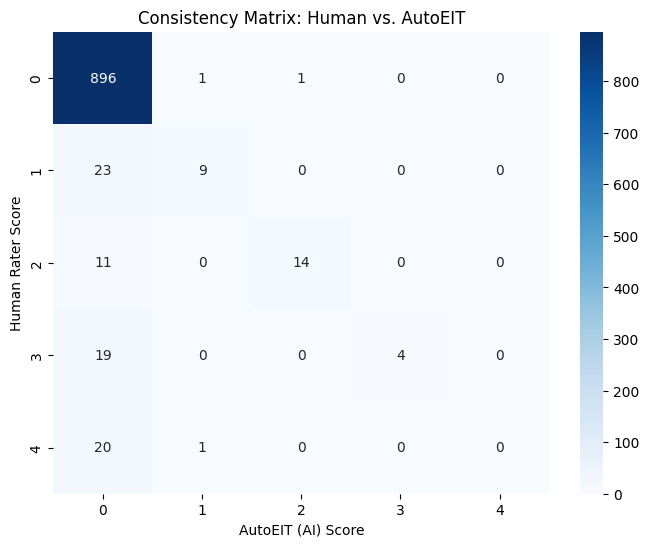

In [24]:
def evaluate_performance(df):
    h_col = 'Score'
    a_col = 'auto_score'

    df_clean = df.dropna(subset=[h_col, a_col]).copy()
    y_true = df_clean[h_col].astype(int)
    y_pred = df_clean[a_col].astype(int)

    accuracy = (y_true == y_pred).mean()
    kappa = cohen_kappa_score(y_true, y_pred)

    print(f"Percentage Agreement: {accuracy * 100:.2f}%")
    print(f"Cohen's Kappa (Reliability): {kappa:.2f}")

    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
    plt.xlabel('AutoEIT (AI) Score')
    plt.ylabel('Human Rater Score')
    plt.title('Consistency Matrix: Human vs. AutoEIT')
    plt.show()

evaluate_performance(df)

In [ ]:
# Save to CSV
df.to_csv("/content/AutoEIT_Final_Report.csv", index=False)